In [52]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, roc_auc_score, f1_score

import torch 
from torch import nn
from PIL import Image
from torchvision import transforms

# Deep Visual Style Recognition Across Domains

### A deep learning study of cross-domain art-versus-photo classification

## Abstract

This project extends a previous classical machine learning study on visual style classification by moving from handcrafted visual descriptors to deep learned representations. The earlier Visual Style Classification with Handcrafted Features project showed that handcrafted features such as HOG, LBP, and Gabor filters can achieve strong performance in a constructed WikiArt-versus-Unsplash classification setting. However, the analysis also revealed an important limitation: source-domain bias. A metadata-only diagnostic showed that technical image properties can strongly separate the datasets, meaning that high classification performance may partly reflect dataset-specific artefacts rather than generalizable visual style patterns.

This project addresses that limitation by using a multi-source dataset design and deep learning models to evaluate whether learned visual representations generalize better across domains. The project compares a convolutional neural network trained from scratch with transfer learning based on pretrained CNN architectures, with a primary focus on ResNet18. The task remains a binary classification problem between artistic images and real-world photographic images, but the data is expanded to include multiple distinct sources for each class.

Model performance is evaluated under both random stratified splits and stricter cross-dataset splits, where models are trained on one pair of art/photo sources and tested on unseen sources. This makes it possible to distinguish between closed-domain performance and cross-domain generalization. In addition, metadata-only diagnostics, learning curves, confusion matrices, embedding visualizations, and Grad-CAM analysis are used to interpret model behaviour and inspect whether the models rely on meaningful visual structure or dataset-specific artefacts.

The central goal is not only to improve classification performance, but to investigate whether deep learned visual representations can generalize beyond the original source-biased experimental setup and provide a stronger basis for art-versus-photo classification across domains.

## Introduction

Deep learning has become the dominant approach in modern computer vision because convolutional neural networks can learn visual representations directly from image data. Unlike classical machine learning pipelines, which depend on manually designed features such as entropy, edge density, HOG, LBP, or Gabor filters, deep learning models can learn hierarchical representations of visual structure from pixels.

This project builds directly on the findings of the previous Visual Style Classification with Handcrafted Features project, a classical machine learning study focused on distinguishing artistic images from natural photographs using handcrafted visual descriptors. That project demonstrated that compact texture- and frequency-based descriptors can perform surprisingly well. In particular, LBP and Gabor feature fusion achieved strong classification performance while using far fewer dimensions than HOG. However, the project also identified a major limitation: the WikiArt-versus-Unsplash dataset construction introduced source-domain bias. The classifier may have learned technical differences between datasets rather than purely general visual differences between artwork and photography.

The present project therefore asks a new question: can deep learned representations improve cross-domain generalization in visual style classification?

To answer this question, the project uses a multi-source dataset design. The artistic class is represented by images from WikiArt and ArtBench, while the photographic class is represented by images from Places365 and a COCO subset. This design reduces dependence on a single source per class and enables cross-dataset evaluation. Models are first evaluated on a standard random stratified split and then on stricter cross-dataset splits, where training and testing sources are intentionally separated.

The project compares three main modelling approaches: a metadata-only baseline for bias diagnostics, a CNN trained from scratch, and transfer learning using a pretrained ResNet18 model. The final analysis focuses not only on accuracy and ROC-AUC, but also on generalization gaps, error patterns, feature embeddings, and qualitative Grad-CAM explanations.

This project is therefore not simply a deep learning replacement for the previous ML pipeline. It is a continuation of the same research question under a stronger experimental design: from handcrafted representations in a closed domain to learned representations evaluated across domains.

## Research Question and Hypotheses

The previous handcrafted-feature project showed that strong classification performance can be achieved in a closed WikiArt-versus-photo setup. However, it also revealed that dataset-specific technical artefacts may strongly influence the task. Therefore, the central question of this project is not only whether a deep learning model can classify artistic and photographic images, but whether it can generalize across unseen visual data sources.

The main research question is:

**Can deep learned visual representations improve cross-dataset generalization in art-versus-photo classification compared to a source-biased handcrafted-feature setup?**

This question is evaluated through the following hypotheses:

**H1 — Metadata bias hypothesis:**  
Technical image metadata such as resolution, aspect ratio, file size, and file format may contain strong source-domain signal. If metadata-only models achieve high performance, random split results must be interpreted carefully.

**H2 — Transfer learning hypothesis:**  
A CNN pretrained on ImageNet (ResNet18 in this project) is expected to outperform a CNN trained from scratch, because it starts from general visual representations learned from large-scale image data.

**H3 — Cross-dataset generalization hypothesis:**  
Random stratified split performance is expected to be higher than cross-dataset performance. Cross-dataset evaluation is therefore used as a stricter test of whether the model learns transferable visual structure rather than source-specific artefacts.

**H4 — Interpretability hypothesis:**  
Grad-CAM and error analysis can provide qualitative evidence about whether model decisions are influenced by meaningful visual regions or by dataset-specific visual artefacts.

## Relation to the Previous Project's Review

The review of the previous handcrafted-features project raised three concerns. This project is explicitly designed around them.

**1. "Metadata almost certainly recognizes the data source, and capture artefacts can leak into the features."**
This concern is treated as a first-class research question here. The metadata-only diagnostic quantifies exactly how much of the task can be solved from technical file properties alone, and the cross-dataset splits are constructed so that source-specific shortcuts stop working at test time instead of silently inflating the score.

**2. "For a stronger claim, split the data by artist and add an external cross-source test."**
The external cross-source test is the central evaluation setup of this project: two cross-dataset splits train on one art/photo source pair and test on completely different, unseen sources. In addition, an artist-disjoint split is included, in which no artist appears in both training and test data, so the model cannot benefit from memorizing an individual artist's style.

**3. "Consider increasing the input resolution."**
All deep learning experiments use 224×224 inputs, chosen to match ImageNet-pretrained architectures. The effect of higher input resolution is discussed in the Limitations section, and the pipeline supports larger inputs through a single configuration change.

## Dataset Design

The project uses a balanced multi-source dataset design. Instead of assigning each class to a single dataset source, each class is represented by two independent image sources. This is important because if one class comes from only one dataset and the other class comes from only one different dataset, the classification task may become a dataset-identification task rather than a visual-style classification task.

The artistic class consists of:

- **WikiArt** — artistic images from multiple artists, periods, and styles;
- **ArtBench** — a structured artwork benchmark dataset with multiple artistic styles.

The photographic class consists of:

- **Places365** — real-world scene photographs;
- **COCO** — real-world photographic images from everyday scenes.

For the main experiment, the project samples 10,000 images from each source dataset, resulting in 40,000 images in total:

| Source dataset | Class | Number of images |
|---|---:|---:|
| WikiArt | art | 10,000 |
| ArtBench | art | 10,000 |
| Places365 | photo | 10,000 |
| COCO | photo | 10,000 |

This produces a balanced binary classification dataset with 20,000 artistic images and 20,000 photographic images.

The goal of this design is not to remove all possible bias, which is unrealistic for real-world image datasets, but to reduce dependence on a single source per class and make cross-dataset evaluation possible.

## Dataset Manifest and Split Strategy

A central dataset manifest is created to make the data selection and split assignment reproducible. The manifest stores the image path, binary label, class name, source dataset, original metadata where available, and the split assignment for each experiment.

The manifest contains the following key columns:

| Column | Meaning |
|---|---|
| `image_path` | Relative path to the image file |
| `label` | Binary target: 1 for art, 0 for photo |
| `class_name` | Human-readable class name: art or photo |
| `source_dataset` | Original dataset source: WikiArt, ArtBench, Places365, or COCO |
| `original_split` | Original train/test split when available, mainly for ArtBench |
| `original_style` | Original ArtBench style category when available |
| `split_random` | Standard random train/validation/test split |
| `split_cross_a` | Cross-dataset split A |
| `split_cross_b` | Cross-dataset split B |
| `artist` | Artist identifier parsed from the filename (art images only) |
| `split_artist` | Artist-disjoint random split |

Four split strategies are used.

### Random stratified split

The random split mixes all four source datasets while preserving class and source balance. It provides a standard closed-domain benchmark.

### Cross-dataset split A

In this setting, the model is trained on WikiArt and Places365 and tested on ArtBench and COCO.

| Role | Sources |
|---|---|
| Train/validation | WikiArt + Places365 |
| Test | ArtBench + COCO |

### Cross-dataset split B

In this setting, the model is trained on ArtBench and COCO and tested on WikiArt and Places365.

| Role | Sources |
|---|---|
| Train/validation | ArtBench + COCO |
| Test | WikiArt + Places365 |

### Artist-disjoint split

This split addresses a different leakage channel: artist identity. In the random split, works by the same artist can appear in both training and test data, so part of the measured performance may come from recognizing an individual artist's style rather than a general art-versus-photo distinction. In the artist-disjoint split, all artworks are grouped by artist (parsed from the WikiArt and ArtBench filenames) and each artist is assigned to exactly one of train, validation, or test. Photo images have no artist and follow the same stratified 70/15/15 procedure as the random split.

Unlike the cross-dataset splits, all four sources remain present in every partition. The artist-disjoint split therefore isolates artist leakage specifically, while the cross-dataset splits isolate source leakage.

The cross-dataset splits are the central evaluation setup of this project. They test whether models can generalize to unseen sources instead of only performing well when the same dataset sources appear in both training and test data.

## Metadata Bias Diagnostic

Before training deep learning models, the project performs a metadata-only diagnostic. The purpose of this step is to test whether technical image properties alone can predict the class label or the source dataset.

The metadata features include:

- image width;
- image height;
- aspect ratio;
- file size;
- log-transformed file size;
- megapixels;
- number of channels;
- landscape/portrait/square indicators;
- file extension.

These features do not describe semantic image content. They only describe technical properties of the image files. Therefore, strong metadata-only performance indicates possible source-domain bias.

Two classifiers are compared for each experiment: a Dummy baseline and a Random Forest. If the Random Forest clearly beats the Dummy baseline using metadata alone, the dataset contains a technical signal that is unrelated to visual content. The results are presented in the next section.

### Metadata Diagnostic Results

The metadata-only diagnostic reveals a strong technical source-domain signal in the dataset. Under the random stratified split, a Random Forest classifier trained only on technical image metadata reaches very high performance for art-versus-photo classification.

This result is important because the model does not use image content in the usual visual sense. It does not receive learned CNN features, handcrafted visual descriptors, or semantic information. It only receives technical properties such as image resolution, aspect ratio, file size, number of channels, and file extension.

The random split result therefore shows that technical image properties are strongly correlated with the class labels when all source datasets are mixed across train and test partitions. In this setting, metadata alone is sufficient to separate art and photo images with very high performance.

However, the cross-dataset splits show a very different pattern. When the metadata model is trained on one pair of art/photo sources and tested on a different pair of unseen sources, performance collapses. This means that the metadata model is not learning a stable art-versus-photo distinction. Instead, it learns source-specific technical patterns that do not transfer consistently across datasets.

This finding supports the first hypothesis of the project: random split performance can be strongly influenced by source-domain artefacts and must therefore be interpreted carefully.

### Source-Level Metadata Distribution

To understand why the metadata-only model behaves this way, it is useful to inspect the technical properties of each source dataset separately. The most important source-level differences are expected to appear in features such as image resolution, megapixels, and file size.

In the current dataset design, the four sources do not have identical technical distributions. All ArtBench and Places365 images are exactly 256×256 pixels, because both datasets are distributed in pre-resized form. WikiArt images are typically much larger (median ≈ 1382×1448 pixels, median file size ≈ 380 KB), and COCO sits in between (median 640×480, ≈ 150 KB). File extension, by contrast, carries no signal at all: all 40,000 sampled images are JPEG files. These resolution and file-size signatures are exactly what the feature importance table shows the Random Forest exploiting: file size and its log transform, megapixels, and image dimensions dominate the ranking.

This explains why source-dataset classification is also very strong. The model can identify whether an image comes from WikiArt, ArtBench, Places365, or COCO using metadata alone. Therefore, source identity is technically visible in the dataset.

### Explaining the Cross-Dataset Inversion

The most important result is not only that metadata performance drops under cross-dataset evaluation, but that it can become almost perfectly inverted.

This happens because the technical relationship between class and source changes across the cross-dataset splits.

In cross-dataset split B, the model is trained on ArtBench and COCO. In this training pair, ArtBench represents the art class and often contains small 256×256 images, while COCO represents the photo class and has a different resolution and file-size distribution. A metadata-only model can therefore learn a rule similar to:

**small technical size → art**
**larger technical size → photo**

However, in the test pair for cross-dataset split B, the sources are WikiArt and Places365. WikiArt represents the art class but often contains much larger images, while Places365 represents the photo class and contains many small 256×256 scene images. This reverses the technical relationship learned during training.

As a result, the metadata model applies a source-specific rule that becomes systematically wrong on the unseen test sources. In split A this collapses performance to 0.38 accuracy with a ROC-AUC of almost exactly zero (0.0035); in split B the inversion is complete, with both accuracy and ROC-AUC equal to 0.0. The model is not randomly guessing — a random model would score around 0.5 — it is applying a perfectly inverted technical rule.

This is a strong demonstration of source-domain bias. It shows that a model can perform extremely well under a random split while completely failing under a source-separated evaluation.

### Implication for Deep Learning Experiments

The metadata diagnostic motivates the rest of the project. Since technical metadata alone can almost perfectly separate classes under a random split, deep learning models should not be evaluated only under random train-test conditions.

The key question is whether CNN-based visual representations can generalize better than metadata-only patterns when evaluated on unseen source datasets.

Image resizing and normalization will remove some direct metadata signals, such as original image resolution and file size, from the model input. However, this does not guarantee that all source-domain bias is removed. Dataset-specific visual artefacts may still remain, including compression patterns, borders, color distributions, cropping style, texture sharpness, and source-specific image quality.

For this reason, the main evaluation of the deep learning models must include cross-dataset splits. Random split performance will be treated as a closed-domain benchmark, while cross-dataset performance will be treated as the stronger test of visual generalization.

In [53]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

metadata_features = pd.read_csv(
    PROCESSED_DIR / "metadata_features.csv"
)

metadata_results = pd.read_csv(
    PROCESSED_DIR / "metadata_bias_results.csv"
)

metadata_feature_importance = pd.read_csv(
    PROCESSED_DIR / "metadata_bias_feature_importance.csv"
)

metadata_results

,experiment,target,split_column,model,train_size,test_size,accuracy,auc,precision_macro,recall_macro,f1_macro
0,Metadata-only art/photo classification - rando...,art_photo_label,split_random,Dummy Classifier,28000,6000,0.5000,0.5000,0.2500,0.5000,0.3333
1,Metadata-only art/photo classification - rando...,art_photo_label,split_random,Random Forest,28000,6000,0.9683,0.9901,0.9683,0.9683,0.9683
2,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Dummy Classifier,16000,20000,0.5000,0.5000,0.2500,0.5000,0.3333
3,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,16000,20000,0.3841,0.0035,0.2172,0.3841,0.2775
4,Metadata-only art/photo classification - cross B,art_photo_label,split_cross_b,Dummy Classifier,16000,20000,0.5000,0.5000,0.2500,0.5000,0.3333
5,Metadata-only art/photo classification - cross B,art_photo_label,split_cross_b,Random Forest,16000,20000,0.0000,0.0000,0.0000,0.0000,0.0000
6,Metadata-only source dataset classification,source_dataset,split_random,Dummy Classifier,28000,6000,0.2500,0.5000,0.0625,0.2500,0.1000
7,Metadata-only source dataset classification,source_dataset,split_random,Random Forest,28000,6000,0.9683,0.9934,0.9683,0.9683,0.9683


In [54]:
source_metadata_summary = (
    metadata_features
    .groupby(["source_dataset", "class_name"])
    .agg(
        image_count=("image_path", "count"),
        median_width=("width", "median"),
        median_height=("height", "median"),
        median_aspect_ratio=("aspect_ratio", "median"),
        median_file_size_kb=("file_size_kb", "median"),
        median_megapixels=("megapixels", "median"),
    )
    .reset_index()
    .sort_values(["class_name", "source_dataset"])
)

source_metadata_summary


,source_dataset,class_name,image_count,median_width,median_height,median_aspect_ratio,median_file_size_kb,median_megapixels
0,artbench,art,10000,256.0,256.0,1.000000,31.302246,0.065536
3,wikiart,art,10000,1382.0,1447.5,0.954750,380.427734,2.545644
1,coco,photo,10000,640.0,480.0,1.333333,150.409668,0.273920
2,places365,photo,10000,256.0,256.0,1.000000,13.112305,0.065536


In [55]:
top_metadata_importance = (
    metadata_feature_importance
    .sort_values(
        ["experiment", "importance"],
        ascending=[True, False],
    )
    .groupby("experiment")
    .head(8)
    .reset_index(drop=True)
)

top_metadata_importance

,experiment,target,split_column,model,feature,importance
0,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,megapixels,0.203426
1,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,file_size_kb,0.195215
2,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,log_file_size_kb,0.190070
3,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,height,0.159902
4,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,width,0.156701
5,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,is_square,0.064289
6,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,is_portrait,0.013694
7,Metadata-only art/photo classification - cross A,art_photo_label,split_cross_a,Random Forest,aspect_ratio,0.011865
8,Metadata-only art/photo classification - cross B,art_photo_label,split_cross_b,Random Forest,megapixels,0.275137
9,Metadata-only art/photo classification - cross B,art_photo_label,split_cross_b,Random Forest,width,0.188506


In [56]:
NUMERIC_METADATA_COLUMNS = [
    "width",
    "height",
    "aspect_ratio",
    "file_size_kb",
    "log_file_size_kb",
    "megapixels",
    "channels",
    "is_landscape",
    "is_portrait",
    "is_square",
]

CATEGORICAL_METADATA_COLUMNS = [
    "file_extension",
]


def build_metadata_matrix(df):
    numeric_features = df[NUMERIC_METADATA_COLUMNS].copy()

    categorical_features = pd.get_dummies(
        df[CATEGORICAL_METADATA_COLUMNS],
        dummy_na=False,
        dtype=float,
    )

    return pd.concat(
        [
            numeric_features.reset_index(drop=True),
            categorical_features.reset_index(drop=True),
        ],
        axis=1,
    )


X_metadata = build_metadata_matrix(metadata_features)

cross_b_train_mask = metadata_features["split_cross_b"] == "train"
cross_b_test_mask = metadata_features["split_cross_b"] == "test"

X_train_cross_b = X_metadata.loc[cross_b_train_mask].copy()
X_test_cross_b = X_metadata.loc[cross_b_test_mask].copy()

y_train_cross_b = metadata_features.loc[
    cross_b_train_mask,
    "label",
].copy()

y_test_cross_b = metadata_features.loc[
    cross_b_test_mask,
    "label",
].copy()

metadata_rf_cross_b = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

metadata_rf_cross_b.fit(
    X_train_cross_b,
    y_train_cross_b,
)

y_pred_cross_b = metadata_rf_cross_b.predict(
    X_test_cross_b
)

cross_b_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        y_test_cross_b,
        y_pred_cross_b,
        labels=[0, 1],
    ),
    index=["True photo", "True art"],
    columns=["Predicted photo", "Predicted art"],
)

cross_b_confusion_matrix

,Predicted photo,Predicted art
True photo,0,10000
True art,10000,0


The confusion matrix confirms that the cross-dataset failure is not a random collapse. The metadata-only classifier systematically transfers a technical rule learned from the training sources to a test setting where the relationship between metadata and class is reversed. In split B this produces a perfectly inverted prediction pattern: every one of the 20,000 test images is assigned to the wrong class.

This result strengthens the motivation for cross-dataset evaluation. A model can appear extremely strong under a random split while learning patterns that do not represent transferable art-versus-photo visual structure.

## Deep Learning Methodology

After establishing the presence of metadata and source-domain bias, the project moves to deep learning models trained directly on image data. The goal of this stage is not only to improve classification performance, but to evaluate whether learned visual representations are more transferable across dataset sources than technical metadata patterns.

All images are loaded from the central dataset manifest. This ensures that the same image selection and split definitions are used consistently across all deep learning experiments. The manifest-based design also prevents accidental differences between models caused by reading folders independently or re-sampling the data.

The deep learning pipeline follows a supervised binary classification setup:

| Component            | Description                                                      |
| -------------------- | ---------------------------------------------------------------- |
| Input                | RGB image                                                        |
| Target               | Binary label: art or photo                                       |
| Positive class       | art                                                              |
| Negative class       | photo                                                            |
| Main random split    | Balanced random train/validation/test split                      |
| Cross-dataset splits | Source-separated train/test configurations                       |
| Main models          | CNN from scratch and ResNet18 transfer learning                  |
| Main metrics         | Accuracy, ROC-AUC, precision, recall, F1-score, confusion matrix |

## Evaluation Metrics

The project evaluates all models using multiple metrics rather than relying on accuracy alone. This is important because accuracy may hide differences in error patterns, class behaviour, and ranking quality.

The main metrics are:

| Metric           | Meaning                                             |
| ---------------- | --------------------------------------------------- |
| Accuracy         | Percentage of correctly classified images           |
| ROC-AUC          | Ability to separate art and photo across thresholds |
| Precision        | How reliable positive predictions are               |
| Recall           | How many true positives are found                   |
| F1-score         | Balance between precision and recall                |
| Confusion matrix | Detailed view of correct and incorrect predictions  |

ROC-AUC is treated as one of the most important metrics because it evaluates how well the model ranks art images above photo images independently of a fixed decision threshold.

Confusion matrices are used to inspect the direction of mistakes. For example, a high number of artworks predicted as photos may indicate that some artistic images are visually close to photographic content, while many photos predicted as art may indicate that stylized photography overlaps with artistic visual structure.

### Image Preprocessing

Deep learning models require tensors with consistent dimensions, while the source images differ strongly in resolution and aspect ratio. All experiments therefore use a fixed 224×224 input resolution and ImageNet channel normalization (mean [0.485, 0.456, 0.406], std [0.229, 0.224, 0.225]), so that the CNN from scratch and the later transfer learning models receive identical inputs.

| Stage | Transformations |
|---|---|
| Training | Resize to 256 → RandomResizedCrop 224 (scale 0.80–1.0) → random horizontal flip (p = 0.5) → color jitter (brightness/contrast/saturation ±10 %, hue ±0.02) → normalize |
| Validation / test | Resize to 256 → CenterCrop 224 → normalize |

The augmentation is intentionally mild: the task depends on visual style and texture, and aggressive transformations could destroy the signal the model is expected to learn.

### Training Strategy

All CNN experiments share the same training configuration:

| Component | Value |
|---|---|
| Loss function | Binary cross-entropy with logits (`BCEWithLogitsLoss`) |
| Optimizer | AdamW, learning rate 1e-3, weight decay 1e-4 |
| Batch size | 8 |
| Epoch budget | Up to 8 epochs |
| Early stopping | Patience 3, monitored on validation ROC-AUC |
| Checkpointing | Best validation ROC-AUC model saved and used for testing |
| Precision | Mixed precision (AMP) on GPU |
| Random seed | 42 |

The best checkpoint is selected on the validation set rather than at the final epoch, because a model can keep improving on the training set while degrading on unseen data. Early stopping matters especially in this project: a model that overfits is likely to latch onto source-specific structure that works in the random split but fails across datasets.

## CNN Trained from Scratch

The first deep learning baseline is a convolutional neural network trained from scratch. This model starts with randomly initialized weights and learns all visual features directly from the project dataset.

The purpose of this model is to answer the following question:

**How much visual structure can a small CNN learn from the project dataset without pretrained visual knowledge?**

A CNN trained from scratch provides an important baseline because it does not rely on external image representations. If it performs well on the random split but poorly on cross-dataset splits, this may indicate that the model learns source-specific visual patterns rather than transferable art-versus-photo features.

The architecture is intentionally small and interpretable — four convolutional blocks followed by a global pooling classifier, with roughly 0.39 M trainable parameters:

| Block | Layers |
|---|---|
| Block 1 | Conv 3×3, 3→32 → BatchNorm → ReLU → MaxPool 2×2 |
| Block 2 | Conv 3×3, 32→64 → BatchNorm → ReLU → MaxPool 2×2 |
| Block 3 | Conv 3×3, 64→128 → BatchNorm → ReLU → MaxPool 2×2 |
| Block 4 | Conv 3×3, 128→256 → BatchNorm → ReLU → MaxPool 2×2 |
| Head | Adaptive average pooling → Dropout 0.5 → Linear 256→1 (single logit) |

Each block halves the spatial resolution and doubles the number of channels, so the network extracts increasingly abstract visual patterns while staying small enough to train quickly. This model is the first deep learning baseline against which the transfer learning models are compared.

### Training Setup

The CNN from scratch was trained on the full balanced multi-source dataset of 40,000 images, using the shared preprocessing and training configuration described in the methodology section (224×224 inputs, AdamW, batch size 8, up to 8 epochs with early stopping on validation ROC-AUC).

The batch size and epoch budget were chosen as a practical trade-off between input resolution, training time, and available GPU memory on local hardware. The purpose of this model is to provide a controlled baseline, not an exhaustively optimized custom architecture.

One consequence of the fixed epoch budget should be stated explicitly: for the random split, validation ROC-AUC was still improving at the final epoch (0.9654 at epoch 7 → 0.9719 at epoch 8), so training stopped at the epoch limit rather than through early stopping. The random split numbers below should therefore be read as a lower bound for this architecture.

The model was evaluated under three settings:

| Experiment | Split column | Purpose |
|---|---|---|
| `cnn_scratch_random` | `split_random` | Closed-domain benchmark |
| `cnn_scratch_cross_a` | `split_cross_a` | Cross-dataset generalization test A |
| `cnn_scratch_cross_b` | `split_cross_b` | Cross-dataset generalization test B |
| `cnn_scratch_artist` | `split_artist` | Artist-disjoint benchmark |

In [57]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports" / "assets" / "cnn_scratch"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

cnn_results = pd.read_csv(PROCESSED_DIR / "cnn_scratch_results.csv")
cnn_history = pd.read_csv(PROCESSED_DIR / "cnn_scratch_history.csv")
cnn_predictions = pd.read_csv(PROCESSED_DIR / "cnn_scratch_predictions.csv")

In [58]:
cnn_results_display = cnn_results[
    [
        "experiment",
        "split_column",
        "image_size",
        "batch_size",
        "train_size",
        "val_size",
        "test_size",
        "best_epoch",
        "accuracy",
        "auc",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "tn",
        "fp",
        "fn",
        "tp",
    ]
].copy()

cnn_results_display

,experiment,split_column,image_size,batch_size,train_size,val_size,test_size,best_epoch,accuracy,auc,precision_macro,recall_macro,f1_macro,tn,fp,fn,tp
0,cnn_scratch_random,split_random,224,8,28000,6000,6000,8,0.9043,0.9706,0.9066,0.9043,0.9042,2825,175,399,2601
1,cnn_scratch_cross_a,split_cross_a,224,8,16000,4000,20000,7,0.0900,0.0338,0.0900,0.0900,0.0900,880,9120,9080,920
2,cnn_scratch_cross_b,split_cross_b,224,8,16000,4000,20000,8,0.1543,0.0551,0.1303,0.1543,0.1404,270,9730,7184,2816
3,cnn_scratch_artist,split_artist,224,8,27908,5933,6159,8,0.8974,0.9698,0.9032,0.8959,0.8967,2512,488,144,3015
4,cnn_std_random,split_random,224,8,28000,6000,6000,7,0.8962,0.9578,0.8962,0.8962,0.8962,2689,311,312,2688
5,cnn_std_cross_a,split_cross_a,224,8,16000,4000,20000,7,0.6130,0.6703,0.6330,0.6130,0.5979,4192,5808,1932,8068
6,cnn_std_cross_b,split_cross_b,224,8,16000,4000,20000,8,0.5080,0.4826,0.5080,0.5080,0.5080,5066,4934,4906,5094
7,cnn_std_artist,split_artist,224,8,27908,5933,6159,8,0.8998,0.9669,0.9013,0.9007,0.8998,2803,197,420,2739


### CNN from Scratch Results

Under the random stratified split, the CNN reaches 0.904 accuracy and 0.971 ROC-AUC. A small convolutional model trained purely from pixels can therefore separate art from photo images very well — as long as all four sources appear in both training and test data.

Under both cross-dataset splits, performance does not merely drop to chance level: it collapses far below it (ROC-AUC 0.034 for split A and 0.055 for split B). Even though the CNN never sees explicit metadata such as file size or original resolution, it clearly still learns source-specific visual patterns. The direction and meaning of this collapse are analyzed in the sanity check below, and the standardized-input control later in the notebook tests whether the effect can be removed at the data level.

All eight experiments — four splits on original images and the same four on standardized images — are reported in the results table above and compared side by side in the Standardized-Input Control section.

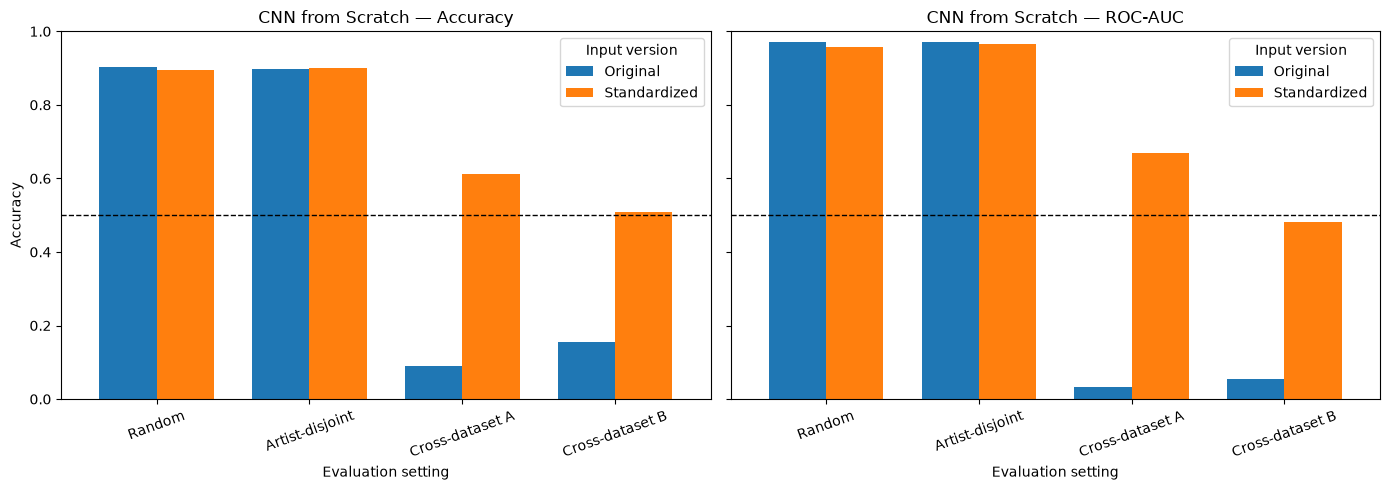

In [59]:
metric_plot_df = cnn_results.copy()

metric_plot_df["dataset_version"] = (
    metric_plot_df["experiment"]
    .str.startswith("cnn_std_")
    .map({True: "Standardized", False: "Original"})
)

metric_plot_df["split_label"] = (
    metric_plot_df["split_column"]
    .str.replace("split_", "", regex=False)
    .replace(
        {
            "random": "Random",
            "cross_a": "Cross-dataset A",
            "cross_b": "Cross-dataset B",
            "artist": "Artist-disjoint",
        }
    )
)

split_order = ["Random", "Artist-disjoint", "Cross-dataset A", "Cross-dataset B"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, metric, metric_label in zip(axes, ["accuracy", "auc"], ["Accuracy", "ROC-AUC"]):
    pivot_df = (
        metric_plot_df
        .pivot_table(index="split_label", columns="dataset_version", values=metric)
        .reindex(split_order)
    )

    pivot_df.plot(kind="bar", ax=ax, rot=20, width=0.75)

    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"CNN from Scratch — {metric_label}")
    ax.set_xlabel("Evaluation setting")
    ax.set_ylabel(metric_label)
    ax.set_ylim(0, 1.0)
    ax.legend(title="Input version")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "cnn_original_vs_standardized.png", dpi=150)
plt.show()

In [60]:
random_row = cnn_results[
    cnn_results["experiment"] == "cnn_scratch_random"
].iloc[0]

cross_rows = cnn_results[
    cnn_results["experiment"].isin(
        [
            "cnn_scratch_cross_a",
            "cnn_scratch_cross_b",
        ]
    )
]

generalization_gap = pd.DataFrame(
    [
        {
            "metric": "accuracy",
            "random_split": random_row["accuracy"],
            "cross_dataset_mean": cross_rows["accuracy"].mean(),
            "generalization_gap": random_row["accuracy"] - cross_rows["accuracy"].mean(),
        },
        {
            "metric": "auc",
            "random_split": random_row["auc"],
            "cross_dataset_mean": cross_rows["auc"].mean(),
            "generalization_gap": random_row["auc"] - cross_rows["auc"].mean(),
        },
        {
            "metric": "f1_macro",
            "random_split": random_row["f1_macro"],
            "cross_dataset_mean": cross_rows["f1_macro"].mean(),
            "generalization_gap": random_row["f1_macro"] - cross_rows["f1_macro"].mean(),
        },
    ]
)

generalization_gap

,metric,random_split,cross_dataset_mean,generalization_gap
0,accuracy,0.9043,0.12215,0.78215
1,auc,0.9706,0.04445,0.92615
2,f1_macro,0.9042,0.11520,0.78900


### Generalization Gap

The table above quantifies the gap between closed-domain and cross-domain performance: accuracy drops by 0.78 and ROC-AUC by 0.93 when moving from the random split to the average of the two cross-dataset splits. A gap of this magnitude means the representation learned by the CNN is dominated by source-specific patterns rather than by transferable art-versus-photo structure.

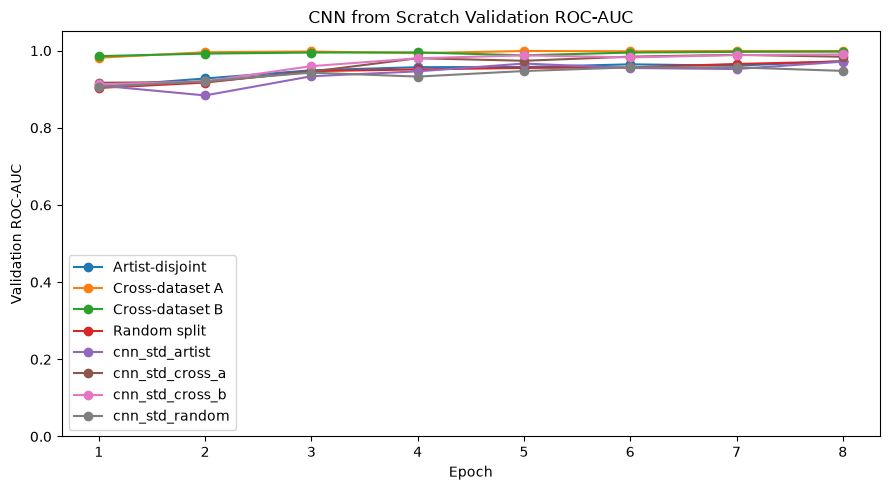

In [61]:
history_plot_df = cnn_history.copy()

history_plot_df["experiment_label"] = history_plot_df["experiment"].replace(
    {
        "cnn_scratch_random": "Random split",
        "cnn_scratch_cross_a": "Cross-dataset A",
        "cnn_scratch_cross_b": "Cross-dataset B",
        "cnn_scratch_artist": "Artist-disjoint",
    }
)

fig, ax = plt.subplots(figsize=(9, 5))

for experiment_label, group_df in history_plot_df.groupby("experiment_label"):
    group_df = group_df.sort_values("epoch")
    ax.plot(
        group_df["epoch"],
        group_df["val_auc"],
        marker="o",
        label=experiment_label,
    )

ax.set_title("CNN from Scratch Validation ROC-AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation ROC-AUC")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig(
    REPORTS_DIR / "cnn_scratch_validation_auc_curves.png",
    dpi=150,
)
plt.show()

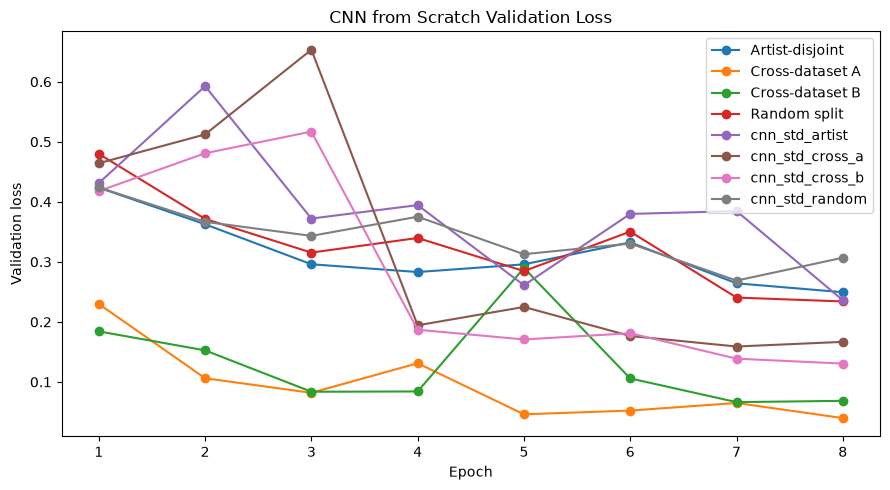

In [62]:
history_plot_df = cnn_history.copy()

history_plot_df["experiment_label"] = history_plot_df["experiment"].replace(
    {
        "cnn_scratch_random": "Random split",
        "cnn_scratch_cross_a": "Cross-dataset A",
        "cnn_scratch_cross_b": "Cross-dataset B",
        "cnn_scratch_artist": "Artist-disjoint",
    }
)

fig, ax = plt.subplots(figsize=(9, 5))

for experiment_label, group_df in history_plot_df.groupby("experiment_label"):
    group_df = group_df.sort_values("epoch")
    ax.plot(
        group_df["epoch"],
        group_df["val_loss"],
        marker="o",
        label=experiment_label,
    )

ax.set_title("CNN from Scratch Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss")
ax.legend()

plt.tight_layout()
plt.savefig(
    REPORTS_DIR / "cnn_scratch_validation_loss_curves.png",
    dpi=150,
)
plt.show()

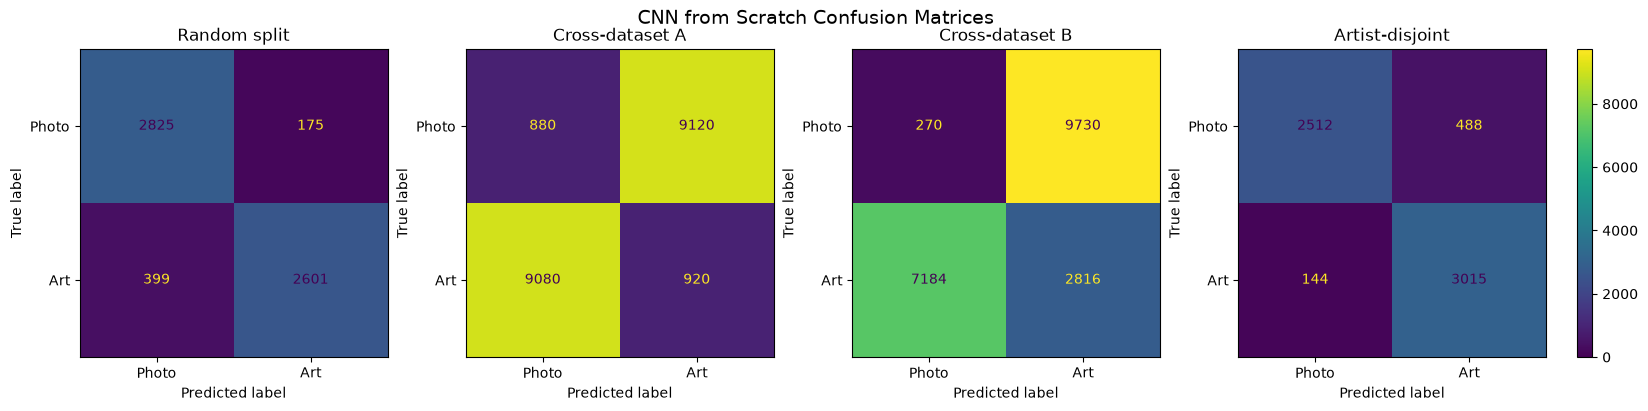

In [63]:
experiment_labels = {
    "cnn_scratch_random": "Random split",
    "cnn_scratch_cross_a": "Cross-dataset A",
    "cnn_scratch_cross_b": "Cross-dataset B",
    "cnn_scratch_artist": "Artist-disjoint",
}

max_count = 0

for experiment in experiment_labels:
    experiment_predictions = cnn_predictions[
        cnn_predictions["experiment"] == experiment
    ].copy()

    cm = confusion_matrix(
        experiment_predictions["y_true"],
        experiment_predictions["y_pred"],
        labels=[0, 1],
    )

    max_count = max(max_count, cm.max())

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20, 4),
)

last_display = None

for ax, (experiment, experiment_label) in zip(
    axes,
    experiment_labels.items(),
):
    experiment_predictions = cnn_predictions[
        cnn_predictions["experiment"] == experiment
    ].copy()

    cm = confusion_matrix(
        experiment_predictions["y_true"],
        experiment_predictions["y_pred"],
        labels=[0, 1],
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Photo",
            "Art",
        ],
    )

    display.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
        im_kw={
            "vmin": 0,
            "vmax": max_count,
        },
    )

    ax.set_title(experiment_label)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    last_display = display

fig.suptitle(
    "CNN from Scratch Confusion Matrices",
    fontsize=14,
)

fig.colorbar(
    last_display.im_,
    ax=axes,
    fraction=0.025,
    pad=0.02,
)

plt.savefig(
    REPORTS_DIR / "cnn_scratch_confusion_matrices.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### Artist-Disjoint Result

The artist-disjoint split keeps all four sources in both training and test data, but assigns each artist to exactly one partition, so no artist's work appears in both training and test. Comparing it with the plain random split separates two leakage channels that the random split confounds.

| Split | Input version | Accuracy | ROC-AUC | F1-score |
|---|---|---:|---:|---:|
| Random | Original | 0.9043 | 0.9706 | 0.9042 |
| Artist-disjoint | Original | 0.8974 | 0.9698 | 0.8967 |
| Random | Standardized | 0.8962 | 0.9578 | 0.8962 |
| Artist-disjoint | Standardized | 0.8998 | 0.9669 | 0.8998 |

Removing artist identity as a shortcut costs almost nothing on either input version: on the original images accuracy falls by less than one percentage point and ROC-AUC is essentially unchanged (0.9706 to 0.9698), and on standardized images the artist-disjoint model is in fact marginally *better* than the random split (0.8998 against 0.8962), which is well within run-to-run noise. Artist memorization is therefore not a meaningful driver of closed-domain performance in this dataset, and the concern raised in the review of the previous project — that a model might be recognizing individual artists rather than art in general — is not supported here.

This result is informative precisely because of how sharply it contrasts with the cross-dataset experiments. The same architecture, trained the same way, loses under 0.01 ROC-AUC when artists are separated but 0.93 ROC-AUC when *sources* are separated. The leakage that inflates the random-split score is not artist-level; it is source-level. The artist-disjoint split acts as a control that isolates which of the two candidate shortcuts is actually doing the work, and the answer is unambiguous.

One caveat applies to the comparison. Artist identity is parsed from WikiArt and ArtBench filenames, so it exists only for the art class; photographs have no artist and follow the same stratified 70/15/15 procedure as the random split. The artist-disjoint split is also marginally larger and less perfectly balanced than the random split (27,908 / 5,933 / 6,159 images against 28,000 / 6,000 / 6,000), because artists are assigned as indivisible groups and vary in how many works they contribute. Both effects are small and do not change the conclusion.

### Sanity Check: Inverted Cross-Dataset Signal

The cross-dataset ROC-AUC values are far below 0.5. This does not simply indicate random failure. Instead, it suggests that the model has learned an inverted source-dependent signal.

If the model were only guessing randomly, the expected ROC-AUC would be close to 0.5. However, ROC-AUC values close to 0 indicate that the model ranks the two classes in the wrong direction on unseen sources.

To verify this behaviour, the predictions are inverted for the two cross-dataset experiments. If the inverted predictions achieve high performance, this supports the interpretation that the model has learned a systematic but non-transferable source-specific signal rather than a stable art-versus-photo representation.

In [64]:
inversion_rows = []

for experiment in [
    "cnn_scratch_cross_a",
    "cnn_scratch_cross_b",
]:
    experiment_predictions = cnn_predictions[
        cnn_predictions["experiment"] == experiment
    ].copy()

    y_true = experiment_predictions["y_true"].to_numpy()
    y_pred = experiment_predictions["y_pred"].to_numpy()
    y_proba = experiment_predictions["y_proba_art"].to_numpy()

    inverted_y_pred = 1 - y_pred
    inverted_y_proba = 1 - y_proba

    inversion_rows.append(
        {
            "experiment": experiment,
            "original_accuracy": accuracy_score(y_true, y_pred),
            "original_auc": roc_auc_score(y_true, y_proba),
            "original_f1_macro": f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            ),
            "inverted_accuracy": accuracy_score(y_true, inverted_y_pred),
            "inverted_auc": roc_auc_score(y_true, inverted_y_proba),
            "inverted_f1_macro": f1_score(
                y_true,
                inverted_y_pred,
                average="macro",
                zero_division=0,
            ),
        }
    )

cnn_inversion_check = pd.DataFrame(inversion_rows)

cnn_inversion_check[
    [
        "experiment",
        "original_accuracy",
        "original_auc",
        "original_f1_macro",
        "inverted_accuracy",
        "inverted_auc",
        "inverted_f1_macro",
    ]
]

,experiment,original_accuracy,original_auc,original_f1_macro,inverted_accuracy,inverted_auc,inverted_f1_macro
0,cnn_scratch_cross_a,0.0900,0.033815,0.089996,0.9100,0.966185,0.910000
1,cnn_scratch_cross_b,0.1543,0.055073,0.140369,0.8457,0.944927,0.843158


The inversion check shows that the cross-dataset failure is systematic rather than random. When the predictions are inverted, performance becomes high. This confirms that the model has learned a strong but reversed signal on unseen datasets.

This is consistent with the metadata diagnostic. In both cases, the model appears to rely on source-dependent patterns that are correlated with the target label in the training sources but reverse in the test sources.

For image-based CNNs, this signal may come from visual artefacts that remain after resizing, such as sharpness, compression patterns, upscaling artefacts, dataset-specific preprocessing, borders, texture statistics, or differences between native image resolutions.

Therefore, the cross-dataset CNN result should not be interpreted as a simple training failure. It is evidence that the model learns a non-transferable source-domain representation.

### Checkpoint Inference Demo

The main experiments are executed through external training scripts because full deep learning training is computationally expensive. However, the trained CNN checkpoint can still be loaded inside the notebook for a small inference demonstration.

This cell loads the best random-split CNN checkpoint and applies it to a small number of test images. The purpose is to demonstrate that the saved model artefact can be reused for inference, not to retrain the model inside the notebook.

In [65]:
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

if "cnn_predictions" not in globals():
    cnn_predictions = pd.read_csv(
        PROCESSED_DIR / "cnn_scratch_predictions.csv"
    )


class VisualStyleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)

        return x.squeeze(1)


def resolve_image_path(image_path: str) -> Path:
    path = Path(image_path)

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


checkpoint_path = MODELS_DIR / "cnn_scratch_random_best.pt"

inference_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ]
)

if checkpoint_path.exists():
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
        )

    demo_model = VisualStyleCNN().to(device)
    demo_model.load_state_dict(checkpoint["model_state_dict"])
    demo_model.eval()

    demo_images = (
        cnn_predictions[
            cnn_predictions["experiment"] == "cnn_scratch_random"
        ]
        .groupby("class_name", group_keys=False)
        .head(3)
        .copy()
    )

    demo_rows = []

    for _, row in demo_images.iterrows():
        image_path = resolve_image_path(row["image_path"])
        image = Image.open(image_path).convert("RGB")

        image_tensor = inference_transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            logit = demo_model(image_tensor)
            probability_art = torch.sigmoid(logit).item()

        predicted_label = int(probability_art >= 0.5)
        predicted_class = "art" if predicted_label == 1 else "photo"

        demo_rows.append(
            {
                "image_path": row["image_path"],
                "true_class": row["class_name"],
                "predicted_class": predicted_class,
                "probability_art": probability_art,
            }
        )

    cnn_checkpoint_demo = pd.DataFrame(demo_rows)

else:
    cnn_checkpoint_demo = pd.DataFrame(
        [
            {
                "status": "Checkpoint not found locally. The notebook can still reproduce the analysis from the saved CSV outputs.",
                "expected_checkpoint": str(checkpoint_path),
            }
        ]
    )

cnn_checkpoint_demo

,image_path,true_class,predicted_class,probability_art
0,data\raw\coco_subset\train2017\000000319738.jpg,photo,photo,0.188765
1,data\raw\places365\val_256\Places365_val_00011...,photo,photo,0.166860
2,data\raw\artbench\artbench-10-imagefolder-spli...,art,art,0.578125
3,data\raw\places365\val_256\Places365_val_00022...,photo,photo,0.300918
4,data\raw\artbench\artbench-10-imagefolder-spli...,art,art,0.588423
5,data\raw\artbench\artbench-10-imagefolder-spli...,art,art,0.630460


### Interpretation

The CNN baseline confirms the concern raised by the metadata diagnostic — but now at the pixel level. The network never receives file size, resolution, or file format, yet resizing every image to 224×224 does not remove the source signal: visual traces such as sharpness after downscaling, compression and upscaling artefacts, and source-specific color statistics remain in the pixels, and they are apparently easier to exploit than genuine stylistic structure.

The random split result should therefore be read as a within-distribution benchmark, not as evidence of generalization. The next step is to test whether pretrained visual representations are more robust: the same three experiments are repeated with ResNet18 transfer learning.

## Transfer Learning with ResNet18

The second modelling approach uses transfer learning with ResNet18. ResNet18 is a convolutional neural network architecture pretrained on ImageNet-1k. Instead of learning all visual features from scratch, the model starts from general-purpose visual representations that already capture edges, textures, shapes, object parts, and scene-level patterns.

Transfer learning is especially useful when the project dataset is smaller than the datasets used to train large modern computer vision models. In this project, ResNet18 is used as the main transfer learning model because it is relatively lightweight, well understood, and suitable for a course-level deep learning project.

Two transfer learning strategies are evaluated.

### ResNet18 Freeze

In the freeze strategy, the pretrained ResNet18 backbone is kept fixed and only the final classification head is trained. This tests whether general pretrained visual features are already sufficient for art-versus-photo classification.

This strategy has several advantages:

| Advantage              | Explanation                                     |
| ---------------------- | ----------------------------------------------- |
| Faster training        | Only a small number of parameters are updated   |
| Lower overfitting risk | Most pretrained weights remain unchanged        |
| Strong baseline        | Tests the usefulness of generic visual features |

However, the frozen model may not adapt deeply enough to the specific visual differences between artistic and photographic images.

### ResNet18 Full Fine-Tuning

In the full fine-tuning strategy, the entire ResNet18 model is trained on the project dataset. This allows the pretrained visual representations to adapt to the art-versus-photo task.

This strategy can potentially improve performance because the model is allowed to learn more task-specific visual patterns. However, it also introduces a higher risk of overfitting, especially if the model learns source-specific artefacts instead of transferable visual structure.

The comparison between frozen transfer learning and full fine-tuning helps answer the following question:

**Does adapting the entire pretrained model improve cross-dataset generalization, or does it mainly improve closed-domain random split performance?**

## Standardized-Input Control

The metadata diagnostic showed that resolution and file size act as a powerful shortcut, and the CNN results showed that a version of this signal survives in the pixels. This section tests the most direct fix at the data level: every image in the dataset is re-encoded to an identical technical format — 256×256 pixels, JPEG quality 90 (`scripts/04_standardize_images.py`). After this transformation, width, height, aspect ratio, megapixels, channel count, and file format are identical for all 40,000 images by construction. The only technical property that can still differ is file size, which now depends purely on image content, since JPEG compresses smooth images more strongly than textured ones.

The metadata diagnostic is then repeated without any changes on the standardized dataset (`scripts/02_metadata_bias_check_standardized.py`), using the same splits, the same features, and the same Dummy and Random Forest models. If standardization works as intended, the metadata-only model should lose most of its power: closed-domain performance should collapse from near-perfect towards the Dummy baseline.

### What Standardization Actually Does

The standardization step (`scripts/04_standardize_images.py`) re-encodes every image in the dataset to an identical technical format. It is deliberately a *re-encoding* step, not a filtering or cleaning step: no image is removed, no duplicate is dropped, and the manifest keeps the same 40,000 rows with the same labels, sources and split assignments. Only the pixel container changes.

| Property | Before | After |
|---|---|---|
| Resolution | 256×256 (ArtBench, Places365) to ≈1650×1656 (WikiArt) | 256×256 for every image |
| Aspect ratio | 0.61 to 1.33 depending on source | 1.0 for every image |
| Megapixels | 0.066 to 2.66 | 0.066 for every image |
| JPEG quality | Source-dependent and unknown | 90 for every image |
| File size | 13 KB to 406 KB by source | Content-dependent only |
| Image count | 40,000 | 40,000 (unchanged) |

The corresponding manifest is written to `data/processed/dataset_manifest_standardized.csv`. It preserves every column of the original manifest — including `split_random`, `split_cross_a`, `split_cross_b` and `split_artist` — so that the standardized experiments run on exactly the same partitions and the two versions remain directly comparable. Two consequences are worth stating explicitly:

- **This is not deduplication.** Near-duplicate images between WikiArt and ArtBench, discussed in the Limitations section, are unaffected and remain a separate open issue.
- **This is a lossy operation.** Downscaling WikiArt images from a median of roughly 1650×1656 to 256×256 discards fine stylistic detail such as brush strokes and canvas texture. The standardized dataset therefore removes the technical shortcut at the cost of some genuine visual signal — which is why the standardized random-split score is expected to be slightly lower rather than higher.

In [66]:
metadata_original = pd.read_csv("data/processed/metadata_bias_results.csv")
metadata_standardized = pd.read_csv(
    "data/processed/metadata_bias_results_standardized.csv"
)

metadata_original["dataset_version"] = "original"
metadata_standardized["dataset_version"] = "standardized"

metadata_comparison = pd.concat(
    [metadata_original, metadata_standardized],
    ignore_index=True,
)

metadata_comparison = metadata_comparison[
    metadata_comparison["model"] == "Random Forest"
]

metadata_comparison[
    ["dataset_version", "experiment", "accuracy", "auc"]
].sort_values(["experiment", "dataset_version"]).reset_index(drop=True)

,dataset_version,experiment,accuracy,auc
0,original,Metadata-only art/photo classification - cross A,0.3841,0.0035
1,standardized,Metadata-only art/photo classification - cross A,0.5278,0.5402
2,original,Metadata-only art/photo classification - cross B,0.0000,0.0000
3,standardized,Metadata-only art/photo classification - cross B,0.5304,0.5498
4,original,Metadata-only art/photo classification - rando...,0.9683,0.9901
5,standardized,Metadata-only art/photo classification - rando...,0.5303,0.5469
6,original,Metadata-only source dataset classification,0.9683,0.9934
7,standardized,Metadata-only source dataset classification,0.2770,0.5404


In [67]:
cnn_version_comparison = cnn_results.copy()

cnn_version_comparison["dataset_version"] = (
    cnn_version_comparison["experiment"]
    .str.startswith("cnn_std_")
    .map({True: "standardized", False: "original"})
)

cnn_version_comparison["split_label"] = (
    cnn_version_comparison["split_column"].str.replace("split_", "", regex=False)
)

cnn_original_vs_std = (
    cnn_version_comparison
    .pivot_table(
        index="split_label",
        columns="dataset_version",
        values=["accuracy", "auc"],
    )
    .reindex(["random", "artist", "cross_a", "cross_b"])
    .round(4)
)

cnn_original_vs_std

accuracy                   auc             
dataset_version original standardized original standardized
split_label                                                
random            0.9043       0.8962   0.9706       0.9578
artist            0.8974       0.8998   0.9698       0.9669
cross_a           0.0900       0.6130   0.0338       0.6703
cross_b           0.1543       0.5080   0.0551       0.4826

In [68]:
cross_source_rows = []

for experiment in [
    "cnn_scratch_cross_a",
    "cnn_scratch_cross_b",
    "cnn_std_cross_a",
    "cnn_std_cross_b",
]:
    experiment_predictions = cnn_predictions[
        cnn_predictions["experiment"] == experiment
    ].copy()

    experiment_predictions["correct"] = (
        experiment_predictions["y_true"] == experiment_predictions["y_pred"]
    ).astype(int)

    grouped = (
        experiment_predictions
        .groupby(["source_dataset", "class_name"])
        .agg(
            accuracy=("correct", "mean"),
            mean_probability_art=("y_proba_art", "mean"),
            image_count=("correct", "size"),
        )
        .reset_index()
    )

    grouped.insert(0, "experiment", experiment)
    cross_source_rows.append(grouped)

cross_dataset_by_source = pd.concat(cross_source_rows, ignore_index=True).round(4)

cross_dataset_by_source

,experiment,source_dataset,class_name,accuracy,mean_probability_art,image_count
0,cnn_scratch_cross_a,artbench,art,0.0920,0.1080,10000
1,cnn_scratch_cross_a,coco,photo,0.0880,0.9006,10000
2,cnn_scratch_cross_b,places365,photo,0.0270,0.9326,10000
3,cnn_scratch_cross_b,wikiart,art,0.2816,0.2788,10000
4,cnn_std_cross_a,artbench,art,0.8068,0.7265,10000
5,cnn_std_cross_a,coco,photo,0.4192,0.5553,10000
6,cnn_std_cross_b,places365,photo,0.5066,0.4998,10000
7,cnn_std_cross_b,wikiart,art,0.5094,0.4894,10000


### Interpretation

On the standardized dataset, the metadata-only Random Forest collapses from 0.968 accuracy and 0.990 ROC-AUC to 0.530 accuracy and 0.547 ROC-AUC on the random split — barely above the Dummy baseline of 0.50. The feature importance table confirms the mechanism: after re-encoding, every geometric feature (width, height, aspect ratio, megapixels) has an importance of exactly zero, because these properties are now constants, and the entire remaining signal is carried by file size alone. That residual signal is content-related rather than pipeline-related: JPEG compresses smooth images more strongly than textured ones, and artworks in this dataset are slightly more texture-dense (median 23.0 KB versus 20.1 KB for photos).

Two further observations complete the metadata picture. First, the cross-dataset inversion disappears entirely: cross-split ROC-AUC moves from ≈0.00 to ≈0.54, meaning the weak remaining signal now transfers across sources instead of flipping sign — exactly what is expected from a content-based rather than source-based feature. Second, the source dataset itself becomes essentially unidentifiable from metadata (0.277 accuracy against a 0.25 four-class baseline).

### The Same Control Applied to the CNN

Repeating all four CNN experiments on the standardized images isolates how much of the pixel-level failure was caused by technically heterogeneous inputs.

| Split | Original acc / AUC | Standardized acc / AUC |
|---|---|---|
| Random | 0.9043 / 0.9706 | 0.8962 / 0.9578 |
| Artist-disjoint | 0.8974 / 0.9698 | 0.8998 / 0.9669 |
| Cross-dataset A | 0.0900 / 0.0338 | 0.6130 / 0.6703 |
| Cross-dataset B | 0.1543 / 0.0551 | 0.5080 / 0.4826 |

The two closed-domain settings are almost unaffected. Random-split ROC-AUC falls from 0.971 to 0.958 and the artist-disjoint setting is unchanged within noise. This is expected: the training pipeline already resized every image to 224×224, so a closed-domain model never depended much on native resolution. The small loss is consistent with genuine stylistic detail — brush strokes, canvas texture — being discarded when WikiArt images are downscaled from a median of roughly 1650×1656 to 256×256.

The cross-dataset settings change completely, and in two different ways.

**The inversion is gone.** On original inputs both cross splits produced ROC-AUC far below 0.5 (0.034 and 0.055): the model transferred a source rule that was systematically wrong on unseen sources. On standardized inputs neither split inverts. Split A reaches 0.670 ROC-AUC and split B 0.483 — the first is a real, if modest, transferable signal, and the second is indistinguishable from chance. Standardization therefore removes the pathological behaviour that the metadata diagnostic predicted, at the pixel level, exactly as it removed it at the metadata level.

**Removing the shortcut does not create generalization.** This is the more important half of the result. Split B lands at 0.508 accuracy and 0.483 ROC-AUC, and the per-source breakdown shows why: Places365 photographs are classified correctly 50.7 % of the time, WikiArt artworks 50.9 %, and the mean predicted probability of "art" is 0.500 for one source and 0.489 for the other. The model is not biased towards either class — it simply carries no usable information about unseen sources at all. Split A retains a weaker version of the old problem instead: 80.7 % accuracy on ArtBench artworks against 41.9 % on COCO photographs, with mean predicted art-probabilities of 0.727 and 0.555, so its ranking is reasonable (ROC-AUC 0.670) while its decision threshold is poorly calibrated for the new domain.

The training curves make the failure mode visible. On standardized cross-dataset split B, validation ROC-AUC climbs to 0.990 by the final epoch while the test ROC-AUC is 0.483. Validation data comes from the training sources; test data does not. A model can therefore look near-perfect throughout training and still hold nothing that transfers — which is precisely why source-separated evaluation, rather than a validation curve, is the meaningful test in this project.

Taken together, the control traces the source bias end to end: detected in the metadata, explained through the resolution inversion, confirmed at the pixel level, and removed by re-encoding. What it does not show is a model that has learned visual style. The original cross-dataset scores were catastrophically wrong; the standardized ones are merely uninformative. Removing a shortcut reveals how much genuine transferable signal a model had learned — and for a small CNN trained from scratch on this data, the honest answer is: very little. Whether ImageNet-pretrained representations do better on the same source-separated splits is the question the transfer learning section addresses.

## Limitations

### Potential Dataset Overlap

A possible limitation of the cross-dataset setup is the potential overlap between WikiArt and ArtBench. ArtBench is an art dataset that may contain images or near-duplicates originating from sources similar to WikiArt. Therefore, the art side of the cross-dataset split may not be perfectly independent.

This does not invalidate the experiment, because the photo datasets and the full source-domain structure are still different. However, it means that the term "unseen source" should be interpreted at the dataset-source level rather than as a guarantee of complete image-level independence.

A stronger future version of the project would include perceptual hash-based near-duplicate detection across all datasets before creating the final splits.

### Input Resolution

All deep learning experiments use 224×224 inputs. This matches ImageNet-pretrained architectures and keeps training feasible on local hardware, but fine stylistic cues such as brush strokes, canvas texture, or film grain may be partially lost at this scale. Increasing the input resolution (for example to 320 or 384 pixels) is a natural extension and requires only a configuration change in the training script, at the cost of proportionally longer training.

### Capture and Encoding Artefacts

Even after resizing, images carry traces of how they were captured and encoded: JPEG compression level, upscaling artefacts, sharpness, and source-specific processing. A standardized-input control — re-encoding every image to identical resolution and JPEG quality before training — removes this technical signal by construction and shows how much of the remaining performance is driven by visual content. This control is implemented in scripts/04_standardize_images.py, and its results are reported in the Standardized-Input Control section above; it directly addresses the capture-artefact concern raised in the review of the previous project.